## Mission 1

- 미션 1. 신고자 성별 분류 대화를 입력 받아서 (음성) -> 남, 여 분류
  - 음성 파일 및 전사 및 annotation 파일 존재 (json) 각 발화 조각들의 정보들
  - 조건: 외부 데이터 사용 불가, 미션에서 제시하는 입출력만 사용
  - 구글, 지피티 등 API를 사용해서 답을 내면 안됨 (우리가 코드를 짜야함)
  - 서울권 데이터만 사용, validation 폴더는 사용 금지(단 early stopping/체크포인트 선정 등 검증 목적은 허용), 샘플 전처리 금지
  - 음성 처리 가이드 제시 (ppt 참고) -> 문제에 따라 유리한 방식이 다를 것
- References:
  - 성능 평가도 진행
  - 학습 모델과 추론 코드를 함께 제출, inference를 돌릴 수 있는 코드를 제출해야 함
  - 불필요한 코드 넣지 말고, 주석은 필수로 달아주기


### 0. GPU 확인

In [ ]:
# 어떤 GPU가 배정됐는지 확인
!nvidia-smi


Sat Sep 26 06:14:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 1. 환경 설정

In [1]:
# ===== 환경 설정 =====
IS_DRIVE = True # Google Drive 마운트해서 쓰는 중이면 True, 로컬 런타임이면 False

if IS_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

!pip install -q librosa soundfile scikit-learn

import os, json, shutil, random, time
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device}, GPU={torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

# 실험 전체에서 공통으로 쓰는 seed 목록 (팀 공통 규칙) - 고정 SEED 하나 대신 실행마다 set_seed(seed)로 지정
SEEDS = [42, 123, 2026]

# 데이터 루트: Drive 마운트 여부에 따라 자동 결정
DRIVE_ROOT = ("/content/drive/MyDrive/projects/AI-DCC/mission1-data" if IS_DRIVE
              else os.path.join(os.path.expanduser("~"), "Downloads", "mission1-data"))

# 실제 폴더 구조 확인 결과 반영 (Training/Validation 각각 원천데이터=오디오, 라벨링데이터=json)
CONFIG = {
    "train_audio_root": os.path.join(DRIVE_ROOT, "Training", "1.원천데이터", "TS_서울_구급"),
    "train_label_root": os.path.join(DRIVE_ROOT, "Training", "2.라벨링데이터", "TL_서울_구급"),
    "val_audio_root":   os.path.join(DRIVE_ROOT, "Validation", "1.원천데이터", "VS_서울_구급"),
    "val_label_root":   os.path.join(DRIVE_ROOT, "Validation", "2.라벨링데이터", "VL_서울_구급"),

    "local_json_dir": "/content/local_json",     # JSON 로컬 복사본 (Drive I/O 병목 회피)
    "local_audio_dir": "/content/local_audio",   # 실제 필요한 오디오만 선택 복사
    "mel_cache_dir": "/content/mel_cache",

    # 팀 공유 Drive 폴더 (체크포인트 / 확률 CSV / history 기록 저장 위치)
    "drive_share_root": "/content/drive/MyDrive/DCC/mission1",  # TODO: 실제 팀 공유 폴더 경로로 수정

    "sample_rate": None,          # 다음 셀에서 실제 파일로 확인 후 채움
    "n_mels": 128,
    "n_fft": 1024,
    "hop_length": 512,
    "target_duration_sec": None,  # EDA 셀에서 train 기준으로만 결정

    "batch_size": 32,
    "epochs": 30,
    "lr_finetune": 1e-4,     # EfficientNet fine-tuning용 학습률
    "early_stop_patience": 5,
}

# 공유 폴더 하위 3개 디렉토리 (약속: ckpt/preds/history)
CONFIG["ckpt_dir"] = os.path.join(CONFIG["drive_share_root"], "ckpt")
CONFIG["preds_dir"] = os.path.join(CONFIG["drive_share_root"], "preds")
CONFIG["history_dir"] = os.path.join(CONFIG["drive_share_root"], "history")

os.makedirs(CONFIG["mel_cache_dir"], exist_ok=True)
os.makedirs(CONFIG["ckpt_dir"], exist_ok=True)
os.makedirs(CONFIG["preds_dir"], exist_ok=True)
os.makedirs(CONFIG["history_dir"], exist_ok=True)


Mounted at /content/drive
device=cuda, GPU=Tesla T4


### 2. 실제 샘플레이트 확인

In [ ]:
# ===== 원본 오디오의 실제 샘플레이트 확인 (전화 음성은 8000Hz인 경우도 많아 가정하지 않고 직접 확인) =====
def find_one_wav(root):
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.endswith(".wav"):
                return os.path.join(dirpath, f)
    return None

sample_wav = find_one_wav(CONFIG["train_audio_root"])
if sample_wav is None:
    raise FileNotFoundError(
        f"wav 파일을 찾지 못했습니다. train_audio_root 경로를 확인하세요: {CONFIG['train_audio_root']}"
    )

info = sf.info(sample_wav)
print(f"샘플 파일: {sample_wav}")
print(f"샘플레이트: {info.samplerate}Hz, 채널: {info.channels}, 길이: {info.duration:.1f}초")
CONFIG["sample_rate"] = info.samplerate


샘플 파일: /content/drive/MyDrive/projects/AI-DCC/mission1-data/Training/1.원천데이터/TS_서울_구급/651e553ba8f14bddba4c1312_20220603.wav
샘플레이트: 8000Hz, 채널: 1, 길이: 142.9초


### 3. 라벨링(JSON) 데이터 로컬 복사

In [ ]:
# ===== JSON 전체를 로컬 디스크로 병렬 복사 (오디오보다 훨씬 가벼워서 빠르게 끝남) =====
# Drive에 마운트된 상태로 JSON 수만 개를 하나씩 열면 매우 느리므로, 먼저 로컬로 복사한 뒤 파싱한다.
from concurrent.futures import ThreadPoolExecutor, as_completed
import uuid

def copy_one_file(src_path, dst_path):
    if os.path.exists(dst_path) and os.path.getsize(dst_path) == os.path.getsize(src_path):
        return True, None
    tmp_path = f"{dst_path}.{uuid.uuid4().hex}.part"  # 스레드별 고유 임시 파일명 -> 레이스 컨디션 차단
    try:
        shutil.copy(src_path, tmp_path)
        os.rename(tmp_path, dst_path)
        return True, None
    except OSError as e:
        return False, str(e)

def copy_json_tree(src_root, dst_root, max_workers=16):
    os.makedirs(dst_root, exist_ok=True)

    # 디렉토리 구조부터 만들고, 복사할 (원본, 대상) 쌍만 먼저 목록화
    tasks = []
    for dirpath, _, filenames in os.walk(src_root):
        rel_dir = os.path.relpath(dirpath, src_root)
        dst_dir = os.path.join(dst_root, rel_dir)
        os.makedirs(dst_dir, exist_ok=True)
        for fname in filenames:
            tasks.append((os.path.join(dirpath, fname), os.path.join(dst_dir, fname)))

    if len(tasks) == 0:
        raise RuntimeError(f"{src_root} 에서 파일을 하나도 찾지 못했습니다. 이 셀을 다시 실행해보세요.")

    print(f"{src_root}: {len(tasks)}개 파일 복사 시작 (병렬 {max_workers}개)")
    failed = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(copy_one_file, s, d): s for s, d in tasks}
        for i, future in enumerate(as_completed(futures)):
            ok, err = future.result()
            if not ok:
                failed.append((futures[future], err))
            if (i + 1) % 5000 == 0:
                print(f"  {i+1}/{len(tasks)} 완료")

    if failed:
        print(f"\n⚠️ {len(failed)}개 파일 복사 실패 — 이 셀을 다시 실행하면 나머지만 이어서 복사합니다.")
    else:
        print(f"복사 완료: {src_root} -> {dst_root} ({len(tasks)}개 파일)")


local_train_label = os.path.join(CONFIG["local_json_dir"], "train")
local_val_label = os.path.join(CONFIG["local_json_dir"], "val")

copy_json_tree(CONFIG["train_label_root"], local_train_label)
copy_json_tree(CONFIG["val_label_root"], local_val_label)


/content/drive/MyDrive/projects/AI-DCC/mission1-data/Training/2.라벨링데이터/TL_서울_구급: 29200개 파일 복사 시작 (병렬 16개)
  5000/29200 완료
  10000/29200 완료
  15000/29200 완료
  20000/29200 완료
  25000/29200 완료
복사 완료: /content/drive/MyDrive/projects/AI-DCC/mission1-data/Training/2.라벨링데이터/TL_서울_구급 -> /content/local_json/train (29200개 파일)
/content/drive/MyDrive/projects/AI-DCC/mission1-data/Validation/2.라벨링데이터/VL_서울_구급: 3640개 파일 복사 시작 (병렬 16개)
복사 완료: /content/drive/MyDrive/projects/AI-DCC/mission1-data/Validation/2.라벨링데이터/VL_서울_구급 -> /content/local_json/val (3640개 파일)


### 4. Manifest 생성 (신고자 발화 + 성별 라벨)

In [ ]:
# ===== 오디오 파일 인덱스 구축 후 _id 기준 매칭 =====
# audioPath 필드는 AI-hub 원본 경로라 실제 배포본(재가공됨)과 다름 -> 실제 파일명(<_id>_<날짜>.wav)으로 매칭

def build_audio_index(audio_root):
    """오디오 폴더를 스캔해 파일명 앞부분(ID)을 key로 하는 조회 테이블 생성"""
    index = {}
    for dirpath, _, filenames in os.walk(audio_root):
        for fname in filenames:
            if not fname.lower().endswith(".wav"):
                continue
            file_id = os.path.splitext(fname)[0].split("_")[0]
            index[file_id] = os.path.join(dirpath, fname)
    return index


def parse_one_json(json_path, audio_index):
    with open(json_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    file_id = meta.get("_id") or meta.get("recordId")
    gender = meta.get("gender")
    utterances = meta.get("utterances", meta.get("utterences", []))

    audio_path = audio_index.get(file_id)
    if audio_path is None:
        return []  # 매칭 실패 -> build_manifest에서 카운트로 확인

    # 약속: call_id = 오디오 파일명(확장자 제외)
    call_id = os.path.splitext(os.path.basename(audio_path))[0]

    records = []
    for utt in utterances:
        if utt.get("speaker") != 1:
            continue
        records.append({
            "call_id": call_id,
            "audio_path": audio_path,
            "start_sec": utt.get("startAt", 0) / 1000.0,
            "end_sec": utt.get("endAt", 0) / 1000.0,
            "gender": gender,
        })
    return records


def build_manifest(local_label_root, audio_root):
    audio_index = build_audio_index(audio_root)
    print(f"오디오 인덱스: {len(audio_index)}개 파일")

    records, matched, total = [], 0, 0
    for dirpath, _, filenames in os.walk(local_label_root):
        for fname in filenames:
            if not fname.endswith(".json"):
                continue
            total += 1
            new_records = parse_one_json(os.path.join(dirpath, fname), audio_index)
            if new_records:
                matched += 1
            records.extend(new_records)
    print(f"매칭된 콜: {matched}/{total}")
    return pd.DataFrame(records)


train_manifest = build_manifest(local_train_label, CONFIG["train_audio_root"])
val_manifest = build_manifest(local_val_label, CONFIG["val_audio_root"])

print(f"\ntrain: {len(train_manifest)}건 ({train_manifest['call_id'].nunique()} calls)")
print(f"val:   {len(val_manifest)}건 ({val_manifest['call_id'].nunique()} calls)")

sample_path = train_manifest["audio_path"].iloc[0]
print(f"\n경로 검증 샘플: {sample_path}")
print("파일 존재 여부:", os.path.exists(sample_path))


오디오 인덱스: 29200개 파일
매칭된 콜: 29200/29200
오디오 인덱스: 3640개 파일
매칭된 콜: 3640/3640

train: 462197건 (29200 calls)
val:   58102건 (3640 calls)

경로 검증 샘플: /content/drive/MyDrive/projects/AI-DCC/mission1-data/Training/1.원천데이터/TS_서울_구급/651e4a6ede6495f4e9d369a5_20220406.wav
파일 존재 여부: True


### 5. 발화 길이 분포 -> target_duration 결정

In [ ]:
# ===== target_duration_sec 결정 (train만 사용, validation 정보로 결정하지 않음) =====
durations = train_manifest["end_sec"] - train_manifest["start_sec"]
print(durations.describe())

CONFIG["target_duration_sec"] = round(float(durations.quantile(0.95)), 2)
print(f"target_duration_sec = {CONFIG['target_duration_sec']}초 (95백분위수 기준)")


count    462197.000000
mean          2.119039
std           1.827057
min           0.009000
25%           0.809000
50%           1.490000
75%           2.826000
max          24.172000
dtype: float64
target_duration_sec = 5.97초 (95백분위수 기준)


### 6. 필요한 오디오만 로컬로 선택 복사

In [ ]:
# ===== manifest에 등장하는 오디오만 로컬 디스크로 병렬 복사 (전체 데이터셋 복사 금지) =====
from concurrent.futures import ThreadPoolExecutor, as_completed

import uuid

def copy_one_audio(src_path, dst_path):
    if os.path.exists(dst_path):
        if os.path.exists(src_path) and os.path.getsize(dst_path) == os.path.getsize(src_path):
            return src_path, dst_path
        os.remove(dst_path)  # 크기 불일치 = 중간에 끊긴 파일 -> 삭제 후 재복사
    if not os.path.exists(src_path):
        return src_path, None
    tmp_path = f"{dst_path}.{uuid.uuid4().hex}.part"  # 스레드별 고유 임시 파일명 -> 이름 충돌로 인한 레이스 컨디션 차단
    shutil.copy(src_path, tmp_path)
    os.rename(tmp_path, dst_path)  # 원자적 복사 -> 중단돼도 손상 파일 안 남음
    return src_path, dst_path

def copy_needed_audio(manifest_df, local_dir, max_workers=8):
    os.makedirs(local_dir, exist_ok=True)
    unique_paths = manifest_df["audio_path"].dropna().unique()
    path_map, missing = {}, 0
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(copy_one_audio, p, os.path.join(local_dir, os.path.basename(p))): p
                   for p in unique_paths}
        for i, future in enumerate(as_completed(futures)):
            src, dst = future.result()
            if dst:
                path_map[src] = dst
            else:
                missing += 1
            if (i + 1) % 2000 == 0:
                print(f"  {i+1}/{len(unique_paths)} 복사 완료")
    if missing:
        print(f"⚠️ 원본을 찾지 못한 파일 {missing}건")
    return path_map

train_path_map = copy_needed_audio(train_manifest, os.path.join(CONFIG["local_audio_dir"], "train"))
val_path_map = copy_needed_audio(val_manifest, os.path.join(CONFIG["local_audio_dir"], "val"))

train_manifest["audio_path"] = train_manifest["audio_path"].map(train_path_map)
val_manifest["audio_path"] = val_manifest["audio_path"].map(val_path_map)

# 복사 실패로 audio_path가 NaN이 된 행 제거
train_manifest = train_manifest.dropna(subset=["audio_path"]).reset_index(drop=True)
val_manifest = val_manifest.dropna(subset=["audio_path"]).reset_index(drop=True)
print(f"최종 train: {len(train_manifest)}건, val: {len(val_manifest)}건")


  2000/29200 복사 완료
  4000/29200 복사 완료
  6000/29200 복사 완료
  8000/29200 복사 완료
  10000/29200 복사 완료
  12000/29200 복사 완료
  14000/29200 복사 완료
  16000/29200 복사 완료
  18000/29200 복사 완료
  20000/29200 복사 완료
  22000/29200 복사 완료
  24000/29200 복사 완료
  26000/29200 복사 완료
  28000/29200 복사 완료
  2000/3640 복사 완료
최종 train: 462197건, val: 58102건


### 7. Mel-Spectrogram 추출

In [ ]:
# ===== log-mel spectrogram 추출 (split별 로컬 캐싱) =====
def extract_mel_spectrogram(audio_path, start_sec, end_sec, call_id, seg_idx, config, split):
    cache_path = os.path.join(config["mel_cache_dir"], f"{split}_{call_id}_{seg_idx}.npy")
    if os.path.exists(cache_path):
        return np.load(cache_path)

    sr = config["sample_rate"]
    y, _ = librosa.load(audio_path, sr=sr, offset=start_sec, duration=end_sec - start_sec)

    target_len = int(config["target_duration_sec"] * sr)
    y = np.pad(y, (0, max(0, target_len - len(y))))[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=config["n_mels"], n_fft=config["n_fft"], hop_length=config["hop_length"]
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)  # 샘플별 정규화

    np.save(cache_path, mel_db.astype(np.float32))
    return mel_db.astype(np.float32)


### 8. Dataset / DataLoader

In [ ]:
# ===== PyTorch Dataset =====
def spec_augment(mel, freq_mask_width=16, time_mask_width=20):
    """SpecAugment: 학습 시에만 주파수/시간 일부를 마스킹해 과적합 억제"""
    mel = mel.copy()
    n_mels, n_frames = mel.shape
    f = np.random.randint(0, freq_mask_width + 1)
    f0 = np.random.randint(0, max(1, n_mels - f))
    mel[f0:f0 + f, :] = mel.mean()
    t = np.random.randint(0, time_mask_width + 1)
    t0 = np.random.randint(0, max(1, n_frames - t))
    mel[:, t0:t0 + t] = mel.mean()
    return mel


class GenderDataset(Dataset):
    def __init__(self, df, config, split, augment=False):
        self.df = df.reset_index(drop=True)
        self.config = config
        self.split = split
        self.augment = augment  # 실험 설정(config)마다 켜고 끌 수 있도록 분리 (base=False)
        self.label_map = {"M": 0, "F": 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mel = extract_mel_spectrogram(row["audio_path"], row["start_sec"], row["end_sec"],
                                       row["call_id"], idx, self.config, self.split)
        if self.augment:
            mel = spec_augment(mel)  # 캐시된 원본은 그대로, 매 epoch 랜덤하게 새로 적용
        return torch.tensor(mel).unsqueeze(0), self.label_map[row["gender"]], row["call_id"]

# DataLoader는 seed/augment 설정이 실행(run)마다 달라지므로 "학습 함수"에서 그때그때 생성합니다.


### 9. 모델 정의 (EfficientNet)

In [ ]:
# ===== 담당 backbone: pretrained EfficientNet-B0 (FAQ Q1 기준 공개 pretrained 모델 사용 허용) =====
class EfficientNetGender(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_b0(weights=weights)

        # mel-spectrogram은 1채널이므로 원래 3채널(RGB)용 첫 conv를 교체
        old_conv = self.backbone.features[0][0]
        new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                              stride=old_conv.stride, padding=old_conv.padding, bias=False)
        if pretrained:
            new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        self.backbone.features[0][0] = new_conv

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


### 10. 학습 함수 (모델 비교를 위해 재사용 가능하도록 함수화)

In [ ]:
# ===== 공통 유틸: seed 고정 + 콜 단위 평가 함수 (팀 전체가 이 함수 하나로 통일) =====
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def compute_call_metrics(call_ids, probs, labels, use_soft_voting=True):
    """발화 단위 예측(prob_F)을 콜 단위로 집계해 Accuracy/F1 계산.
    use_soft_voting=True : 확률 평균 후 0.5 기준 판단 (soft-voting)
    use_soft_voting=False: 발화별 0.5 기준 판정 후 최빈값 (hard 다수결, 'base' 설정용)
    """
    utt_df = pd.DataFrame({"call_id": call_ids, "prob_F": probs, "true": labels})
    call_df = utt_df.groupby("call_id").agg(prob_F=("prob_F", "mean"), true=("true", "first")).reset_index()

    if use_soft_voting:
        call_df["pred"] = (call_df["prob_F"] >= 0.5).astype(int)
    else:
        utt_df["utt_pred"] = (utt_df["prob_F"] >= 0.5).astype(int)
        hard_pred = utt_df.groupby("call_id")["utt_pred"].agg(lambda x: x.mode()[0])
        call_df["pred"] = call_df["call_id"].map(hard_pred)

    acc = accuracy_score(call_df["true"], call_df["pred"])
    f1 = f1_score(call_df["true"], call_df["pred"])
    return utt_df, call_df, acc, f1


# ===== 실험 하나(설정 x seed)를 학습하고 약속된 파일들을 전부 저장 =====
def train_one_run(config_name, run_config, seed, config, train_manifest, val_manifest):
    """
    config_name: "base" / "softvote" / "scheduler" / "classweight" 등 (파일명에 그대로 들어감)
    run_config : {"soft_voting": bool, "lr_scheduler": bool, "class_weight": bool, "spec_augment": bool}
    파일명 규칙: m1_effb0_{config_name}_s{seed}
    """
    set_seed(seed)  # 학습 전 seed 고정

    train_ds = GenderDataset(train_manifest, config, "train", augment=run_config["spec_augment"])
    val_ds = GenderDataset(val_manifest, config, "val", augment=False)
    g = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True,
                               num_workers=2, generator=g)
    val_loader = DataLoader(val_ds, batch_size=config["batch_size"], shuffle=False, num_workers=2)

    model = EfficientNetGender(pretrained=True).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr_finetune"])

    class_weight = None
    if run_config["class_weight"]:
        gender_counts = train_manifest.drop_duplicates("call_id")["gender"].value_counts()
        n_m, n_f = gender_counts.get("M", 1), gender_counts.get("F", 1)
        cw = torch.tensor([1.0 / n_m, 1.0 / n_f], dtype=torch.float32)
        class_weight = (cw / cw.sum() * 2).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weight)

    scheduler = None
    if run_config["lr_scheduler"]:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    scaler = torch.amp.GradScaler("cuda")  # Mixed Precision(AMP) -> 학습 속도 개선

    def run_epoch(loader, train, log_every=100):
        model.train() if train else model.eval()
        total_loss, probs, labels, calls = 0, [], [], []
        t0 = time.time()
        with torch.set_grad_enabled(train):
            for i, (mel, label, call_id) in enumerate(loader):
                mel, label = mel.to(device), label.to(device)
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    logits = model(mel)
                    loss = criterion(logits, label)
                if train:
                    optimizer.zero_grad()
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                total_loss += loss.item() * mel.size(0)
                probs.extend(torch.softmax(logits, dim=1)[:, 1].detach().cpu().tolist())  # prob_F
                labels.extend(label.cpu().tolist())
                calls.extend(call_id)
                if train and (i + 1) % log_every == 0:
                    elapsed = time.time() - t0
                    speed = (i + 1) / elapsed
                    remaining_min = (len(loader) - (i + 1)) / speed / 60
                    print(f"    batch {i+1}/{len(loader)} | 경과 {elapsed/60:.1f}분 | "
                          f"이 에폭 남은 예상 시간 {remaining_min:.1f}분")
        return total_loss / len(loader.dataset), probs, labels, calls

    full_name = f"m1_effb0_{config_name}_s{seed}"
    ckpt_path = os.path.join(config["ckpt_dir"], f"{full_name}_best.pt")
    history_path = os.path.join(config["history_dir"], f"{full_name}_history.csv")
    utt_path = os.path.join(config["preds_dir"], f"{full_name}_utt.csv")
    call_path = os.path.join(config["preds_dir"], f"{full_name}_call.csv")

    best_f1, best_acc, patience_counter = 0.0, 0.0, 0
    history = []
    t0 = time.time()

    for epoch in range(config["epochs"]):
        train_loss, _, _, _ = run_epoch(train_loader, train=True)
        val_loss, val_probs, val_labels, val_calls = run_epoch(val_loader, train=False)

        utt_df, call_df, call_acc, call_f1 = compute_call_metrics(
            val_calls, val_probs, val_labels, use_soft_voting=run_config["soft_voting"]
        )
        current_lr = optimizer.param_groups[0]["lr"]
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss,
                         "val_acc": call_acc, "val_f1": call_f1, "lr": current_lr})
        pd.DataFrame(history).to_csv(history_path, index=False)  # epoch마다 즉시 저장 (중단돼도 기록 보존)

        if scheduler is not None:
            scheduler.step(call_f1)

        print(f"[{full_name}] epoch {epoch+1} train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
              f"val_acc={call_acc:.4f} val_f1={call_f1:.4f} lr={current_lr:.2e}")

        if call_f1 > best_f1:
            best_f1, best_acc, patience_counter = call_f1, call_acc, 0
            torch.save(model.state_dict(), ckpt_path)
            utt_df[["call_id", "prob_F", "true"]].to_csv(utt_path, index=False)
            call_df[["call_id", "prob_F", "pred", "true"]].to_csv(call_path, index=False)
        else:
            patience_counter += 1
            if patience_counter >= config["early_stop_patience"]:
                print(f"[{full_name}] early stopping (patience={config['early_stop_patience']})")
                break

    elapsed_min = (time.time() - t0) / 60
    print(f"[{full_name}] 완료 - best_acc={best_acc:.4f} best_f1={best_f1:.4f} 소요시간={elapsed_min:.1f}분")

    # 기록 양식: 설정/seed/Accuracy/학습시간을 팀 공통 로그 파일에 한 줄 추가 (세션 넘어서도 누적됨)
    log_path = os.path.join(config["drive_share_root"], "runs_log.csv")
    log_row = pd.DataFrame([{
        "config": config_name, "seed": seed, "accuracy": best_acc, "f1": best_f1,
        "elapsed_min": round(elapsed_min, 1),
    }])
    log_row.to_csv(log_path, mode="a", header=not os.path.exists(log_path), index=False)

    return {"config": config_name, "seed": seed, "accuracy": best_acc, "f1": best_f1, "elapsed_min": elapsed_min}


### 11. 학습 실행

In [ ]:
# ===== 실행할 설정 선택 =====
# 진행 순서: "base"를 3 seed로 먼저 돌려서 공유 -> 그 다음 "softvote" -> "scheduler" -> "classweight" 순으로 하나씩 추가
EXPERIMENT_CONFIGS = {
    "base":        {"soft_voting": False, "lr_scheduler": False, "class_weight": False, "spec_augment": False},
    "softvote":    {"soft_voting": True,  "lr_scheduler": False, "class_weight": False, "spec_augment": False},
    "scheduler":   {"soft_voting": True,  "lr_scheduler": True,  "class_weight": False, "spec_augment": False},
    "classweight": {"soft_voting": True,  "lr_scheduler": True,  "class_weight": True,  "spec_augment": False},
}

CONFIG_NAME = "base"  # 다음 차례엔 "softvote" -> "scheduler" -> "classweight" 순으로 바꿔서 이 셀만 재실행

if "all_results" not in globals():
    all_results = []  # 이번 세션에서 실행한 결과 누적 (세션 재시작 시 초기화 -> 최종 집계는 Drive의 runs_log.csv 기준)

for seed in SEEDS:
    result = train_one_run(CONFIG_NAME, EXPERIMENT_CONFIGS[CONFIG_NAME], seed, CONFIG, train_manifest, val_manifest)
    all_results.append(result)

pd.DataFrame(all_results)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 86.3MB/s]


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
    batch 8200/14444 | 경과 10.3분 | 이 에폭 남은 예상 시간 7.8분
    batch 8300/14444 | 경과 10.4분 | 이 에폭 남은 예상 시간 7.7분
    batch 8400/14444 | 경과 10.5분 | 이 에폭 남은 예상 시간 7.6분
    batch 8500/14444 | 경과 10.6분 | 이 에폭 남은 예상 시간 7.4분
    batch 8600/14444 | 경과 10.8분 | 이 에폭 남은 예상 시간 7.3분
    batch 8700/14444 | 경과 10.9분 | 이 에폭 남은 예상 시간 7.2분
    batch 8800/14444 | 경과 11.0분 | 이 에폭 남은 예상 시간 7.1분
    batch 8900/14444 | 경과 11.2분 | 이 에폭 남은 예상 시간 6.9분
    batch 9000/14444 | 경과 11.3분 | 이 에폭 남은 예상 시간 6.8분
    batch 9100/14444 | 경과 11.4분 | 이 에폭 남은 예상 시간 6.7분
    batch 9200/14444 | 경과 11.5분 | 이 에폭 남은 예상 시간 6.6분
    batch 9300/14444 | 경과 11.7분 | 이 에폭 남은 예상 시간 6.5분
    batch 9400/14444 | 경과 11.8분 | 이 에폭 남은 예상 시간 6.3분
    batch 9500/14444 | 경과 11.9분 | 이 에폭 남은 예상 시간 6.2분
    batch 9600/14444 | 경과 12.0분 | 이 에폭 남은 예상 시간 6.1분
    batch 9700/14444 | 경과 12.1분 | 이 에폭 남은 예상 시간 5.9분
    batch 9800/14444 | 경과 12.3분 | 이 에폭 남은 예상 시간 5.8분
    batch 9900/14444 | 경과 12.4분 | 이 에폭 남은 예상 시간 5.7분
    batch 

,config,seed,accuracy,f1,elapsed_min
0,base,42,0.970055,0.972579,323.086266
1,base,123,0.974451,0.976378,356.169669
2,base,2026,0.973626,0.975758,276.157525


### 11b. 결과 기록 표 (설정 x seed, 팀 공통 로그)

In [ ]:
# ===== 기록 양식: 설정 / seed / Accuracy / 학습 시간 표 (Drive 공유 로그 기준, 세션 재시작해도 유지됨) =====
log_path = os.path.join(CONFIG["drive_share_root"], "runs_log.csv")
runs_log = (pd.read_csv(log_path).sort_values(["config", "seed"]).reset_index(drop=True)
            if os.path.exists(log_path) else pd.DataFrame(columns=["config", "seed", "accuracy", "f1", "elapsed_min"]))
runs_log


,config,seed,accuracy,f1,elapsed_min
0,base,42,0.974176,0.976190,237.5
1,base,42,0.970055,0.972579,324.2
2,base,42,0.970055,0.972579,323.1
3,base,123,0.973352,0.975462,186.4
4,base,123,0.974451,0.976378,356.2
5,base,2026,0.973626,0.975782,203.4
6,base,2026,0.973626,0.975758,276.2


### 12. 추론 스크립트 생성 (inference.py) — 실행규칙 준수

실행규칙: `python inference.py --audio_dir ... --label_dir ... --ckpt_path ... --output ...` 형태로 **단일 명령어 실행**이 가능해야 하고, 출력 CSV는 `[audio file name], [gender]` 형식이어야 함. 아래 셀은 노트북 상태와 무관하게 독립적으로 동작하는 `inference.py`를 실제로 파일로 생성한다.

In [ ]:
%%writefile inference.py
"""
Mission 1 추론 스크립트 - 신고자 성별 분류

사용법:
    python inference.py --audio_dir {wav folder} --label_dir {json folder} \
        --ckpt_path {checkpoint file} --output ./outputs/mission1.csv

출력 CSV 컬럼: [audio file name], [gender]
"""
import os
import json
import time
import argparse
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torchvision.models as models

# ===== 학습 시 사용한 값과 반드시 동일해야 함 (이 노트북의 CONFIG 기준) =====
SAMPLE_RATE = 8000
TARGET_DURATION_SEC = 5.97
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512


class EfficientNetGender(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # 추론 시엔 저장된 가중치로 전부 덮어쓸 것이므로 ImageNet pretrained 다운로드 불필요
        self.backbone = models.efficientnet_b0(weights=None)
        old_conv = self.backbone.features[0][0]
        self.backbone.features[0][0] = nn.Conv2d(
            1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
            stride=old_conv.stride, padding=old_conv.padding, bias=False
        )
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


def build_audio_index(audio_dir):
    """오디오 파일명(<id>_<날짜>.wav)에서 ID를 추출해 조회 테이블 생성"""
    index = {}
    for dirpath, _, filenames in os.walk(audio_dir):
        for fname in filenames:
            if not fname.lower().endswith(".wav"):
                continue
            file_id = os.path.splitext(fname)[0].split("_")[0]
            index[file_id] = os.path.join(dirpath, fname)
    return index


def extract_mel_spectrogram(audio_path, start_sec, end_sec):
    y, _ = librosa.load(audio_path, sr=SAMPLE_RATE, offset=start_sec, duration=end_sec - start_sec)
    target_len = int(TARGET_DURATION_SEC * SAMPLE_RATE)
    y = np.pad(y, (0, max(0, target_len - len(y))))[:target_len]
    mel = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    return mel_db.astype(np.float32)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--audio_dir", required=True, help="원천 오디오(wav) 폴더")
    parser.add_argument("--label_dir", required=True, help="라벨링(json) 폴더")
    parser.add_argument("--ckpt_path", required=True, help="학습된 체크포인트(.pt) 경로")
    parser.add_argument("--output", required=True, help="결과 CSV 저장 경로")
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = EfficientNetGender()
    model.load_state_dict(torch.load(args.ckpt_path, map_location=device))
    model.to(device)
    model.eval()

    audio_index = build_audio_index(args.audio_dir)
    inv_label_map = {0: "M", 1: "F"}
    BATCH_SIZE = 16

    tasks = []
    call_task_idx = {}
    for dirpath, _, filenames in os.walk(args.label_dir):
        for fname in filenames:
            if not fname.endswith(".json"):
                continue
            with open(os.path.join(dirpath, fname), "r", encoding="utf-8") as f:
                meta = json.load(f)

            file_id = meta.get("_id") or meta.get("recordId")
            audio_path = audio_index.get(file_id)
            if audio_path is None:
                continue

            utterances = meta.get("utterances", meta.get("utterences", []))
            reporter_segs = [u for u in utterances if u.get("speaker") == 1]
            if not reporter_segs:
                reporter_segs = utterances

            for utt in reporter_segs:
                start_sec = utt.get("startAt", 0) / 1000.0
                end_sec = utt.get("endAt", 0) / 1000.0
                if end_sec <= start_sec:
                    continue
                call_task_idx.setdefault(audio_path, []).append(len(tasks))
                tasks.append((audio_path, start_sec, end_sec))

    print(f"총 {len(tasks)}개 발화 추론 시작 ({len(call_task_idx)}개 오디오 파일)")

    all_probs = [None] * len(tasks)
    t0 = time.time()
    for b in range(0, len(tasks), BATCH_SIZE):
        batch = tasks[b:b + BATCH_SIZE]
        mels = [extract_mel_spectrogram(p, s, e) for p, s, e in batch]
        x = torch.tensor(np.stack(mels)).unsqueeze(1).to(device)
        with torch.no_grad():
            batch_probs = torch.softmax(model(x), dim=1)[:, 1].cpu().tolist()
        for j, p in enumerate(batch_probs):
            all_probs[b + j] = p
        if (b // BATCH_SIZE + 1) % 50 == 0:
            done = b + len(batch)
            elapsed = time.time() - t0
            remaining_min = (len(tasks) - done) / (done / elapsed) / 60
            print(f"  {done}/{len(tasks)} | 경과 {elapsed/60:.1f}분 | 남은 예상 {remaining_min:.1f}분")

    rows = []
    for audio_path, idxs in call_task_idx.items():
        avg_prob = sum(all_probs[i] for i in idxs) / len(idxs)
        pred = 1 if avg_prob >= 0.5 else 0
        rows.append({
            "audio file name": os.path.basename(audio_path),
            "gender": inv_label_map[pred],
        })

    out_dir = os.path.dirname(args.output)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    pd.DataFrame(rows).to_csv(args.output, index=False)
    print(f"저장 완료: {args.output} ({len(rows)}건)")


if __name__ == "__main__":
    main()

Writing inference.py


In [ ]:
import subprocess

ckpt_path = os.path.join(CONFIG["ckpt_dir"], "m1_effb0_base_s42_best.pt")
print("체크포인트 존재 여부:", os.path.exists(ckpt_path))

cmd = [
    "python", "-u", "inference.py",  # -u: 출력 버퍼링 없이 즉시 내보냄
    "--audio_dir", CONFIG["val_audio_root"],
    "--label_dir", CONFIG["val_label_root"],
    "--ckpt_path", ckpt_path,
    "--output", "./outputs/mission1.csv",
]

process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in process.stdout:
    print(line, end="")
process.wait()

if process.returncode == 0:
    print(pd.read_csv("./outputs/mission1.csv").head())
else:
    print(f"실패 (exit code {process.returncode})")

체크포인트 존재 여부: True
총 58102개 발화 추론 시작 (3640개 오디오 파일)
  800/58102 | 경과 0.3분 | 남은 예상 21.6분
  1600/58102 | 경과 0.4분 | 남은 예상 14.5분
  2400/58102 | 경과 0.6분 | 남은 예상 14.0분
  3200/58102 | 경과 0.7분 | 남은 예상 12.6분
  4000/58102 | 경과 0.9분 | 남은 예상 12.0분
  4800/58102 | 경과 1.0분 | 남은 예상 11.6분
  5600/58102 | 경과 1.2분 | 남은 예상 11.0분
  6400/58102 | 경과 1.3분 | 남은 예상 10.9분
  7200/58102 | 경과 1.5분 | 남은 예상 10.5분
  8000/58102 | 경과 1.7분 | 남은 예상 10.4분
  8800/58102 | 경과 1.8분 | 남은 예상 10.1분
  9600/58102 | 경과 2.0분 | 남은 예상 9.9분
  10400/58102 | 경과 2.1분 | 남은 예상 9.8분
  11200/58102 | 경과 2.3분 | 남은 예상 9.6분
  12000/58102 | 경과 2.5분 | 남은 예상 9.5분
  12800/58102 | 경과 2.6분 | 남은 예상 9.2분
  13600/58102 | 경과 2.8분 | 남은 예상 9.1분
  14400/58102 | 경과 2.9분 | 남은 예상 8.8분
  15200/58102 | 경과 3.1분 | 남은 예상 8.8분
  16000/58102 | 경과 3.2분 | 남은 예상 8.5분
  16800/58102 | 경과 3.4분 | 남은 예상 8.4분
  17600/58102 | 경과 3.5분 | 남은 예상 8.1분
  18400/58102 | 경과 3.7분 | 남은 예상 8.0분
  19200/58102 | 경과 3.8분 | 남은 예상 7.8분
  20000/58102 | 경과 4.0분 | 남은 예상 7.7분
  20800/58102 | 경과 4.1분 | 

### 13. 성능 그래프 (Accuracy / F1-Score)

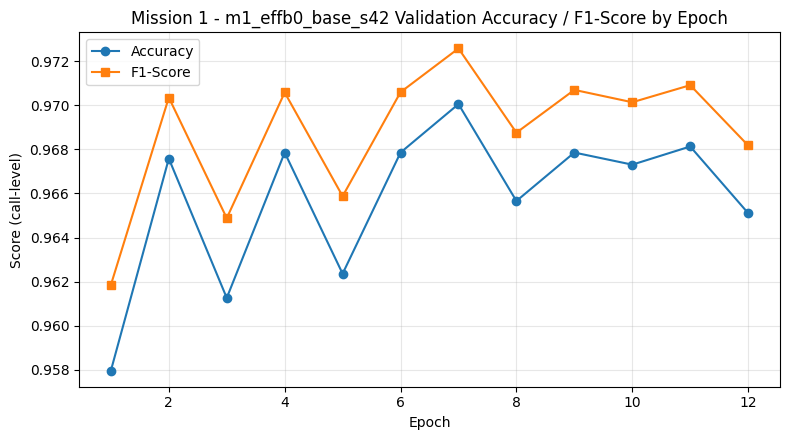

In [ ]:
# ===== Epoch별 Validation Accuracy / F1-Score 그래프 (저장된 history CSV 기준) =====
import matplotlib.pyplot as plt

PLOT_RUN_NAME = "m1_effb0_base_s42"  # 그래프로 보고 싶은 실행(config+seed)으로 교체
history_df = pd.read_csv(os.path.join(CONFIG["history_dir"], f"{PLOT_RUN_NAME}_history.csv"))

plt.figure(figsize=(8, 4.5))
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Accuracy")
plt.plot(history_df["epoch"], history_df["val_f1"], marker="s", label="F1-Score")
plt.xlabel("Epoch")
plt.ylabel("Score (call-level)")
plt.title(f"Mission 1 - {PLOT_RUN_NAME} Validation Accuracy / F1-Score by Epoch")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"/content/{PLOT_RUN_NAME}_metrics.png", dpi=150)
plt.show()


### 14. 앙상블 (Seed 평균)

In [ ]:
# ===== 여러 실행(run)의 콜 단위 확률(prob_F)을 평균내 앙상블 성능 확인 (재학습 불필요) =====
def ensemble_predictions(run_names, config, save_name=None):
    merged = None
    for name in run_names:
        path = os.path.join(config["preds_dir"], f"{name}_call.csv")
        df = pd.read_csv(path)[["call_id", "prob_F", "true"]].rename(columns={"prob_F": f"prob_{name}"})
        merged = df if merged is None else merged.merge(df[["call_id", f"prob_{name}"]], on="call_id", how="inner")

    prob_cols = [c for c in merged.columns if c.startswith("prob_")]
    merged["prob_F_ensemble"] = merged[prob_cols].mean(axis=1)
    merged["pred"] = (merged["prob_F_ensemble"] >= 0.5).astype(int)

    acc = accuracy_score(merged["true"], merged["pred"])
    f1 = f1_score(merged["true"], merged["pred"])

    if save_name:
        out_path = os.path.join(config["preds_dir"], f"{save_name}_call.csv")
        merged[["call_id", "prob_F_ensemble", "pred", "true"]].rename(
            columns={"prob_F_ensemble": "prob_F"}
        ).to_csv(out_path, index=False)

    return merged, acc, f1


# base 3 seed 앙상블 (이미 저장된 콜 단위 확률만 평균 -> 재학습 없음)
ensemble_runs = ["m1_effb0_base_s42", "m1_effb0_base_s123", "m1_effb0_base_s2026"]
_, ens_acc, ens_f1 = ensemble_predictions(ensemble_runs, CONFIG, save_name="m1_effb0_base_ensemble")

seed_results = runs_log[runs_log["config"] == "base"]  # 11b 셀에서 불러온 결과 재사용
print(f"개별 seed 평균 - Accuracy: {seed_results['accuracy'].mean():.4f}, F1: {seed_results['f1'].mean():.4f}")
print(f"3-seed 앙상블  - Accuracy: {ens_acc:.4f}, F1: {ens_f1:.4f}")


개별 seed 평균 - Accuracy: 0.9728, F1: 0.9750
3-seed 앙상블  - Accuracy: 0.9775, F1: 0.9791


In [ ]:
import shutil

zip_dir = "/content/mission1_base_results"
os.makedirs(zip_dir, exist_ok=True)

for seed in [42, 123, 2026]:
    full_name = f"m1_effb0_base_s{seed}"
    shutil.copy(os.path.join(CONFIG["preds_dir"], f"{full_name}_call.csv"), zip_dir)
    shutil.copy(os.path.join(CONFIG["preds_dir"], f"{full_name}_utt.csv"), zip_dir)
    shutil.copy(os.path.join(CONFIG["history_dir"], f"{full_name}_history.csv"), zip_dir)

shutil.make_archive("/content/mission1_base_results", "zip", zip_dir)
print("압축 완료: /content/mission1_base_results.zip")

압축 완료: /content/mission1_base_results.zip


In [2]:
from sklearn.metrics import confusion_matrix

seeds = [42, 123, 2026]
calls = {s: pd.read_csv(os.path.join(CONFIG["preds_dir"], f"m1_effb0_base_s{s}_call.csv")).set_index("call_id")
         for s in seeds}
base = calls[42]

# 1) 3 seed 모두 틀린 콜 = 진짜 어려운 콜 또는 라벨 이상 후보
wrong_sets = [set(df.index[df["pred"] != df["true"]]) for df in calls.values()]
always_wrong = set.intersection(*wrong_sets)
print(f"콜 수: {len(base)}, seed별 오답: {[len(w) for w in wrong_sets]}")
print(f"3 seed 모두 오답: {len(always_wrong)}개 / 한 번이라도 오답: {len(set.union(*wrong_sets))}개")

# 2) 오답의 확신도: 틀렸는데 확률이 0/1에 가까우면 라벨 노이즈 의심
avg_prob = pd.concat([df["prob_F"] for df in calls.values()], axis=1).mean(axis=1).reindex(base.index)
wrong_conf = avg_prob[list(always_wrong)]
conf_wrong = ((wrong_conf < 0.1) | (wrong_conf > 0.9)).sum()
print(f"상시 오답 중 확신 오답(prob<0.1 또는 >0.9): {conf_wrong}/{len(always_wrong)}")

# 3) 혼동행렬 (행: 실제 M,F / 열: 예측 M,F)
true = base["true"]
pred = (avg_prob >= 0.5).astype(int)
print(confusion_matrix(true, pred))

# 4) 발화 수별 오답률 (발화가 적은 콜이 더 틀리는지)
utt = pd.read_csv(os.path.join(CONFIG["preds_dir"], "m1_effb0_base_s42_utt.csv"))
n_utt = utt.groupby("call_id").size().rename("n_utt")
tmp = pd.concat([n_utt, pred.ne(true).rename("wrong")], axis=1)
tmp["bucket"] = pd.cut(tmp["n_utt"], [0, 3, 6, 10, 20, 1000])
print(tmp.groupby("bucket", observed=True)["wrong"].agg(["mean", "count"]))

콜 수: 3640, seed별 오답: [109, 93, 96]
3 seed 모두 오답: 65개 / 한 번이라도 오답: 136개
상시 오답 중 확신 오답(prob<0.1 또는 >0.9): 5/65
[[1634   47]
 [  35 1924]]
                mean  count
bucket                     
(0, 3]      0.000000      6
(3, 6]      0.017544     57
(6, 10]     0.017182    582
(10, 20]    0.020917   2247
(20, 1000]  0.032086    748


In [5]:
stats = []
for s in seeds:
    u = pd.read_csv(os.path.join(CONFIG["preds_dir"], f"m1_effb0_base_s{s}_utt.csv"))
    stats.append(u.groupby("call_id").agg(n_utt=("prob_F", "size"),
                                          frac_F=("prob_F", lambda x: (x > 0.5).mean())))
call_stats = pd.concat(stats).groupby(level=0).mean()
call_stats["true"] = base["true"]
call_stats["frac_correct"] = np.where(call_stats["true"] == 1, call_stats["frac_F"], 1 - call_stats["frac_F"])

bad = call_stats.loc[list(always_wrong)]
print(pd.cut(bad["frac_correct"], [-0.01, 0.2, 0.5, 1.0]).value_counts().sort_index())

frac_correct
(-0.01, 0.2]    16
(0.2, 0.5]      49
(0.5, 1.0]       0
Name: count, dtype: int64
